Marcos Lopes (PECE/USP) -- 2025

# Mac-Morpho

Corpus de sentenças cuja fonte são notícias da Folha de S. Paulo no ano de 1994. Etiquetado morfossintaticamente por humanos (padrão ouro).

In [1]:
# Download do corpus

import nltk
nltk.download('mac_morpho')


[nltk_data] Downloading package mac_morpho to
[nltk_data]     C:\Users\mathe\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\mac_morpho.zip.


True

In [2]:
# Uso das sentenças não etiquetadas (como se fosse um corpus de texto "puro")

sents = nltk.corpus.mac_morpho.sents()
sents[:2]


[['Jersei',
  'atinge',
  'média',
  'de',
  'Cr$',
  '1,4',
  'milhão',
  'em',
  'a',
  'venda',
  'de',
  'a',
  'Pinhal',
  'em',
  'São',
  'Paulo'],
 ['Programe',
  'sua',
  'viagem',
  'a',
  'a',
  'Exposição',
  'Nacional',
  'do',
  'Zebu',
  ',',
  'que',
  'começa',
  'dia',
  '25']]

In [3]:
# Palavras etiquetadas

palavras_etiquetas = nltk.corpus.mac_morpho.tagged_words()
print(palavras_etiquetas[:5])
print(len(palavras_etiquetas))


[('Jersei', 'N'), ('atinge', 'V'), ('média', 'N'), ('de', 'PREP'), ('Cr$', 'CUR')]
1170095


# Criação de um etiquetador morfossintático (POS-tagger)

Impressione seus amigos com um POS-tagger criado inteiramente por você -- e com três linhas de programação...

Antes de começar, vamos aprender a usar o método `get()` dos dicionários do Python. Ele oferece dois recursos importantes:

* Quando se consulta uma chave inexistente, ele não retorna um erro;
* O método permite que seja declarado um valor por default que será automaticamente retornado quando são buscadas chaves inexistentes.

In [4]:
d = {'abacate': 'n', 'beber': 'v'}


In [5]:
d['beber']


'v'

In [6]:
# Lembre-se: chamar uma chave inexistente no dicionário dá erro
d['uva']


KeyError: 'uva'

In [7]:
# Uma solução para o erro de chave é usar o método dict.get()

d = {'abacate': 'n', 'beber': 'v'}
print(d.get('beber', 'Chave desconhecida.'))
print(d.get('uva', 'Chave desconhecida.'))


v
Chave desconhecida.


In [8]:
# Criação do dicionário de etiquetas por Compreensão de Dicionário (não de lista)

dic_pos = {palavra.lower(): pos for (palavra, pos) in palavras_etiquetas}
print(len(dic_pos))
dic_pos['média']


59911


'ADJ'

In [9]:
# Criação de uma função de etiquetagem simplificada,
# baseada no dicionário de etiquetas

def tag(sentenca: str) -> list:
    palavras = sentenca.lower().split()
    return [(p, dic_pos.get(p, '<??>')) for p in palavras]


In [10]:
# Experimente!

tag('Não consigo pensar em uma sentença com uma palavra que não exista no meio daquelas um milhão de palavras')


[('não', 'ADV'),
 ('consigo', 'V'),
 ('pensar', 'V'),
 ('em', 'PREP|+'),
 ('uma', 'ART'),
 ('sentença', 'N'),
 ('com', 'PREP'),
 ('uma', 'ART'),
 ('palavra', 'N'),
 ('que', 'KS'),
 ('não', 'ADV'),
 ('exista', 'V'),
 ('no', 'KC'),
 ('meio', 'NUM'),
 ('daquelas', '<??>'),
 ('um', 'ART'),
 ('milhão', 'N'),
 ('de', 'PREP'),
 ('palavras', 'N')]

# POS-tagging com spaCy

In [13]:
!uv run python -m spacy download pt_core_news_sm


     ---------------------------------------- 0.0/13.0 MB ? eta -:--:--
     ------------------------------- ------- 10.5/13.0 MB 72.5 MB/s eta 0:00:01
     --------------------------------------- 13.0/13.0 MB 45.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')


In [14]:
# Importação do módulo e do modelo de língua
import spacy
nlp = spacy.load('pt_core_news_sm')


In [15]:
# Documento de exemplo
texto = 'Águas passadas não movem moinhos'


In [16]:
# Outro exemplo bobo, mas que mostra que a POS de uma palavra (ex. "francês")
# é alterada conforme o contexto (substantivo ou adjetivo)

texto = 'O pão francês não foi entregue hoje.'


In [17]:
doc = nlp(texto)


In [18]:
for token in doc:
    print(token.text, token.pos_)


O DET
pão NOUN
francês ADJ
não ADV
foi AUX
entregue VERB
hoje ADV
. PUNCT


# Análise de Dependências

In [19]:
doc = nlp('O Filme: O Ultimo Samurai, ganhou o Premio')
for token in doc:
    print(token.text, token.dep_)


O det
Filme nsubj
: punct
O det
Ultimo appos
Samurai flat:name
, punct
ganhou ROOT
o det
Premio obj


In [20]:
# Exibição gráfica das dependências
from spacy import displacy

displacy.render(doc, style='dep', jupyter=True)


In [21]:
# Caso você queira gravar a imagem gerada em arquivo...
from pathlib import Path

svg = displacy.render(doc, style='dep', jupyter=False)
output_path = Path('Minha Sentença.svg')
lixo = output_path.open('w', encoding='utf-8').write(svg)


# Exemplos de aplicação

Esses exemplos vão servir de base para a solução da tarefa de Linguística Forense.

In [1]:
import pandas as pd


In [33]:
# from google.colab import files

# uploaded = files.upload()


In [4]:
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize, word_tokenize


def ler(nome_arquivo) -> str:
    with open(nome_arquivo, 'r', encoding='utf-8') as arquivo:
        return arquivo.read()


# Tokenização de palavras
def tokenizar(txt: str) -> list:
    return word_tokenize(txt, language='portuguese')


# Tokenização de sentenças
def tokenizar_sentencas(txt: str) -> list:
    txt = txt.replace('\n', ' ')
    return sent_tokenize(txt, language='portuguese')


# Limpeza simples
def limpar(lista: list) -> list:
    return [i.lower() for i in lista if i.isalpha()]


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mathe\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [5]:
texto = ler('Guarani.txt')


In [6]:
sents = tokenizar_sentencas(texto)


In [7]:
df_alencar = pd.DataFrame({'Sentencas': sents})
df_alencar.head()


,Sentencas
0,"O Guarani, de José de Alencar Fonte: ALENCAR, ..."
1,O guarani.
2,"20a ed., São Paulo: Ática, 1996 (Bom Livro)."
3,Texto proveniente de: A Biblioteca Virtual do ...
4,Este material pode ser redistribuído livrement...


In [8]:
# O que acontece quando se aplica describe() a strings?

df_alencar.describe()


,Sentencas
count,5778
unique,5571
top,— Oh!
freq,26


In [9]:
# E quanto a contagens de valores?

df_alencar['Sentencas'].value_counts()


Sentencas
— Oh!                                                                                                                                                 26
— Sim!                                                                                                                                                17
— Ah!                                                                                                                                                 17
— Não!                                                                                                                                                10
— Qual?                                                                                                                                                7
                                                                                                                                                      ..
Tu viverás com tua irmã, sempre...!                                     

In [10]:
# Um DataFrame tem seus próprios métodos para strings.
# Seu processamento é mais veloz que os equivalentes em Python (compreensão de listas, por ex.)

df_alencar['TamSentencas'] = df_alencar['Sentencas'].str.len()
df_alencar.head()


,Sentencas,TamSentencas
0,"O Guarani, de José de Alencar Fonte: ALENCAR, ...",54
1,O guarani.,10
2,"20a ed., São Paulo: Ática, 1996 (Bom Livro).",44
3,Texto proveniente de: A Biblioteca Virtual do ...,196
4,Este material pode ser redistribuído livrement...,120


In [11]:
# Mais moleza para a sua vida: função que recebe um nome de arquivo
# e retorna um DataFrame de sentenças com seus tamanhos

def textos_df(arq: str) -> pd.DataFrame:
    txt = ler(arq)
    sentencas = tokenizar_sentencas(txt)
    df_obra = pd.DataFrame({'Sentencas': sentencas})
    df_obra['TamSentencas'] = df_obra['Sentencas'].str.len()

    return df_obra


In [12]:
# Exemplos de aplicação

df_nabuco = textos_df('Abolicionismo.txt')
df_nabuco.head()


,Sentencas,TamSentencas
0,"O Abolicionismo, de Joaquim Nabuco Fonte: NABU...",58
1,O abolicionismo.,16
2,"São Paulo : Publifolha, 2000.",29
3,(Grandes nomes do pensamento brasileiro da Fol...,63
4,Texto proveniente de: A Biblioteca Virtual do ...,196


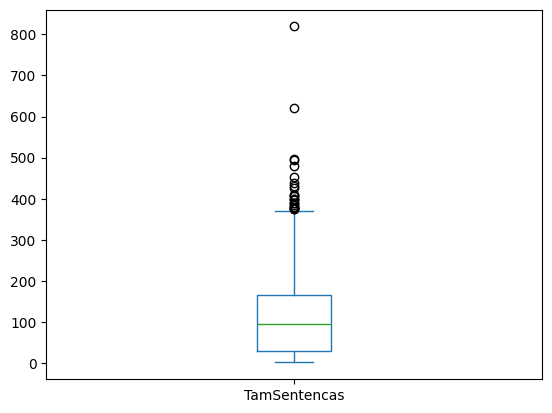

In [13]:
# Uma visualização rápida dos dados numéricos do DataFrame através de um Box Plot

df_alencar.plot.box();


In [ ]:
# Função que recebe uma string e retorna o número de advérbios encontrados nela

def n_advs(sent: str) -> list:
    doc = nlp(sent)
    return len([t.pos_ for t in doc if t.pos_ == 'ADV'])


In [ ]:
n_advs('Teste de não dar nunca nada certo certamente.')


3

In [ ]:
# Aplicação da função a um df

df_alencar['Advs'] = df_alencar['Sentencas'].apply(n_advs)
df_alencar.sample()  # Para exemplificar


,Sentencas,TamSentencas,Advs
5613,"Peri, cada vez mais admirado, ouvia sua senhor...",160,4


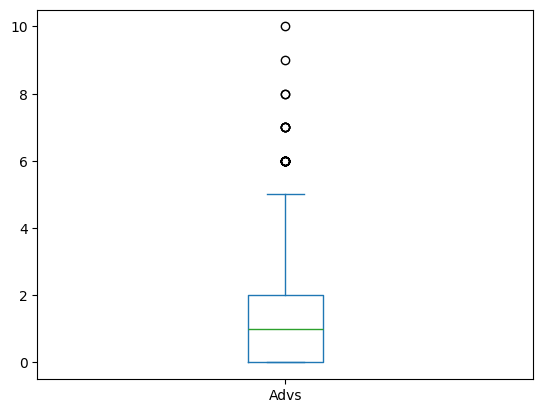

In [ ]:
# Box Plot para os advérbios (semelhante aos de tamanhos de sentenças)

df_alencar['Advs'].plot.box();


In [ ]:
# O módulo matplotlib oferece mais poder e versatilidade com gráficos que o Pandas
# Com ele, fica fácil gerar gráficos diretamente de listas, como faremos a seguir

import matplotlib.pyplot as plt


In [ ]:
df_nabuco.head()


,Sentencas,TamSentencas
0,"O Abolicionismo, de Joaquim Nabuco Fonte: NABU...",58
1,O abolicionismo.,16
2,"São Paulo : Publifolha, 2000.",29
3,(Grandes nomes do pensamento brasileiro da Fol...,63
4,Texto proveniente de: A Biblioteca Virtual do ...,196


In [ ]:
# Vamos acrescentar uma coluna de advérbios aos demais DFs

df_nabuco['Advs'] = df_nabuco['Sentencas'].apply(n_advs)


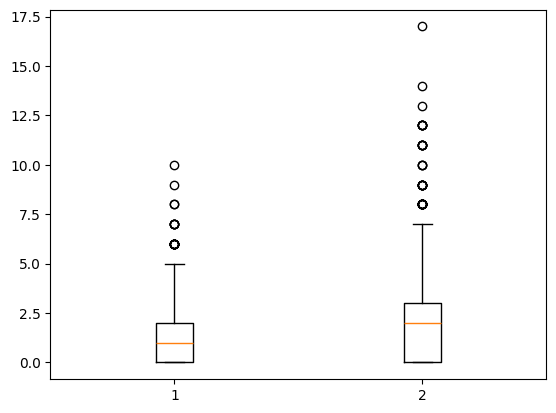

In [ ]:
# Agora, será possível compará-los por box plots

adverbios = [i['Advs'].values.tolist() for i in [df_alencar, df_nabuco]]
plt.boxplot(adverbios);


# Tarefa: Linguística Forense

Seu grupo de especialistas em PLN foi chamado para periciar um texto de autor incógnito. Há três elementos suspeitos de ser o autor da obra. Todos negam veementemente a autoria. São eles:

* Machado de Assis, autor de "Dom Casmurro"
* José de Alencar, autor de "O Guarani"
* Joaquim Nabuco, autor de "O Abolicionismo"

Você tem à disposição esses livros para comparar com o livro apócrifo.

Em suas análises, use alguns dos recursos comuns da Linguística Forense:

* Análise das divisões de período (para simplificar: tamanho das sentenças);
* Comparação das colocações adverbiais, em especial os modais (etiqueta de dependência: "advmod") e as conjunções subordinativas ("que" e "se"; etiqueta: "sconj").

Ao final, responda: quem é o autor do livro apócrifo?